## Init

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re
import numpy as np
import pandas as pd
from scipy.spatial import distance
from scipy.stats import gaussian_kde
from IPython.display import display, HTML

sns.set_theme(style='whitegrid')


In [2]:
### load and aggregate all experiment csvs
RESULTS_DIR = 'results'
TCP_COL = 'unweighted_tcp_score'
csv_files = sorted(glob.glob(f'{RESULTS_DIR}/*/*/*.csv'))
print(f'found {len(csv_files)} result files')

### known strategies - order matters for matching multi-token names first
STRATEGY_LIST = [
    'simple_12_5', 'simple_25', 'simple_37_5', 'simple_50', 'neutral',
]
CLASS_MAP = {
    'simple': 'Simple',
    'neutral': 'Baseline',
}

summary_rows = []
trace_frames = []
for fpath in csv_files:
    df = pd.read_csv(fpath)
    basename = os.path.basename(fpath)
    ### parse objective (tcp or cs)
    objective = 'unknown'
    normalized_path = fpath.replace('\\', '/')
    if '/tcp/' in normalized_path:
        objective = 'tcp'
    elif '/cs/' in normalized_path:
        objective = 'cs'

    ### parse surcharges from directory name
    m = re.search(r'county_(\d+)_coi_(\d+)', fpath)
    county_surcharge = int(m.group(1)) if m else 0
    coi_surcharge = int(m.group(2)) if m else 100
    # match strategy name
    strategy = 'unknown'
    strategy_class = 'Other'
    for s in STRATEGY_LIST:
        if s in basename:
            strategy = s
            strategy_class = CLASS_MAP[s.split('_')[0]]
            break
    ### surcharge label for plotting (e.g. "county 0 / coi 100")
    v_match = re.search(r'_v(\d+)\.csv', fpath)
    replica = f'v{v_match.group(1)}' if v_match else 'v1'
    surcharge_label = f'county {county_surcharge} / coi {coi_surcharge}'
    summary_rows.append({
        'objective': objective,
        'strategy': strategy,
        'strategy_class': strategy_class,
        'county_surcharge': county_surcharge,
        'coi_surcharge': coi_surcharge,
        'surcharge_label': surcharge_label,
        'mean_tcp': df[TCP_COL].mean(),
        'max_tcp': df[TCP_COL].max(),
        'min_tcp': df[TCP_COL].min(),
        'mean_county_splits': df['county_split_count'].mean(),
        
    })


    ### thin trace to every 100th row for plotting
    if 'accepted' in df.columns:
        df['rolling_accept_rate'] = df['accepted'].rolling(1000, min_periods=1).mean()
    else:
        is_accepted = (df[TCP_COL].diff() != 0) | (df['county_split_count'].diff() != 0)
        df['rolling_accept_rate'] = is_accepted.astype(int).rolling(1000, min_periods=1).mean()
    cols_to_keep = ['step', TCP_COL, 'county_split_count', 'rolling_accept_rate', 'communities_split']

    if 'dem_wins' in df.columns:
        cols_to_keep.append('dem_wins')
    share_cols = [c for c in df.columns if 'dem_share' in c]
    cols_to_keep.extend(share_cols)
    t = df[cols_to_keep].iloc[::100].copy()

    if share_cols:
        t['mean_dem_share'] = t[share_cols].mean(axis=1)

    t['strategy'] = strategy
    t['strategy_class'] = strategy_class
    t['county_surcharge'] = county_surcharge
    t['coi_surcharge'] = coi_surcharge
    t['surcharge_label'] = surcharge_label
    t['replica'] = replica
    t['objective'] = objective
    trace_frames.append(t)

master_df = pd.DataFrame(summary_rows)
if len(trace_frames) == 0:
    print('No data found yet. Please run experiments first.')
    traces = pd.DataFrame(columns=['objective', 'strategy', 'surcharge_label'])
else:
    traces = pd.concat(trace_frames, ignore_index=True)
    
### enforce ordering
CLASS_ORDER = ['Simple', 'Baseline']
traces['strategy_class'] = pd.Categorical(traces['strategy_class'], categories=CLASS_ORDER, ordered=True)
import re
surcharge_order = sorted(traces['surcharge_label'].unique(), key=lambda x: int(re.search(r'county (\d+)', x).group(1)), reverse=True)
traces['surcharge_label'] = pd.Categorical(traces['surcharge_label'], categories=surcharge_order, ordered=True)
print(f'loaded {len(master_df)} runs across {traces["surcharge_label"].nunique()} surcharge configs')
display(master_df.head(10))




found 0 result files
No data found yet. Please run experiments first.


KeyError: 'strategy_class'

## TCP Over Steps

how does tcp evolve as the chain runs? smooth, stabilizing climbs suggest
realistic optimization. erratic swings suggest the acceptance function is
too loose or too tight.




### Objective: TCP

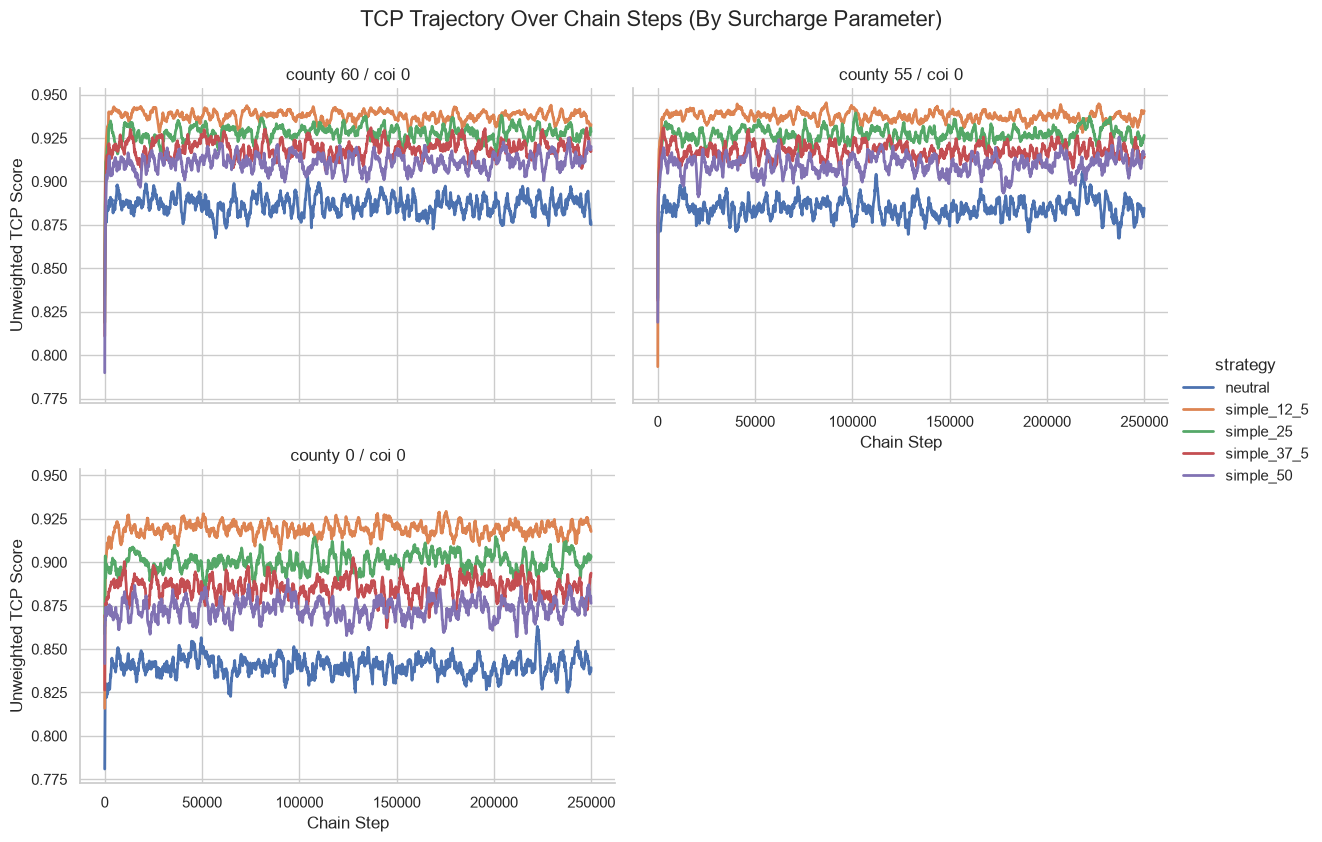

In [4]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### tcp trajectory by strategy, faceted by surcharge config
    grouped_obj_traces = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (By Surcharge Parameter)', y=1.05, fontsize=16)
    plt.show()
    
    

### Objective: CS

In [5]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### tcp trajectory by strategy, faceted by surcharge config
    grouped_obj_traces = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (By Surcharge Parameter)', y=1.05, fontsize=16)
    plt.show()
    
    

### Objective: TCP

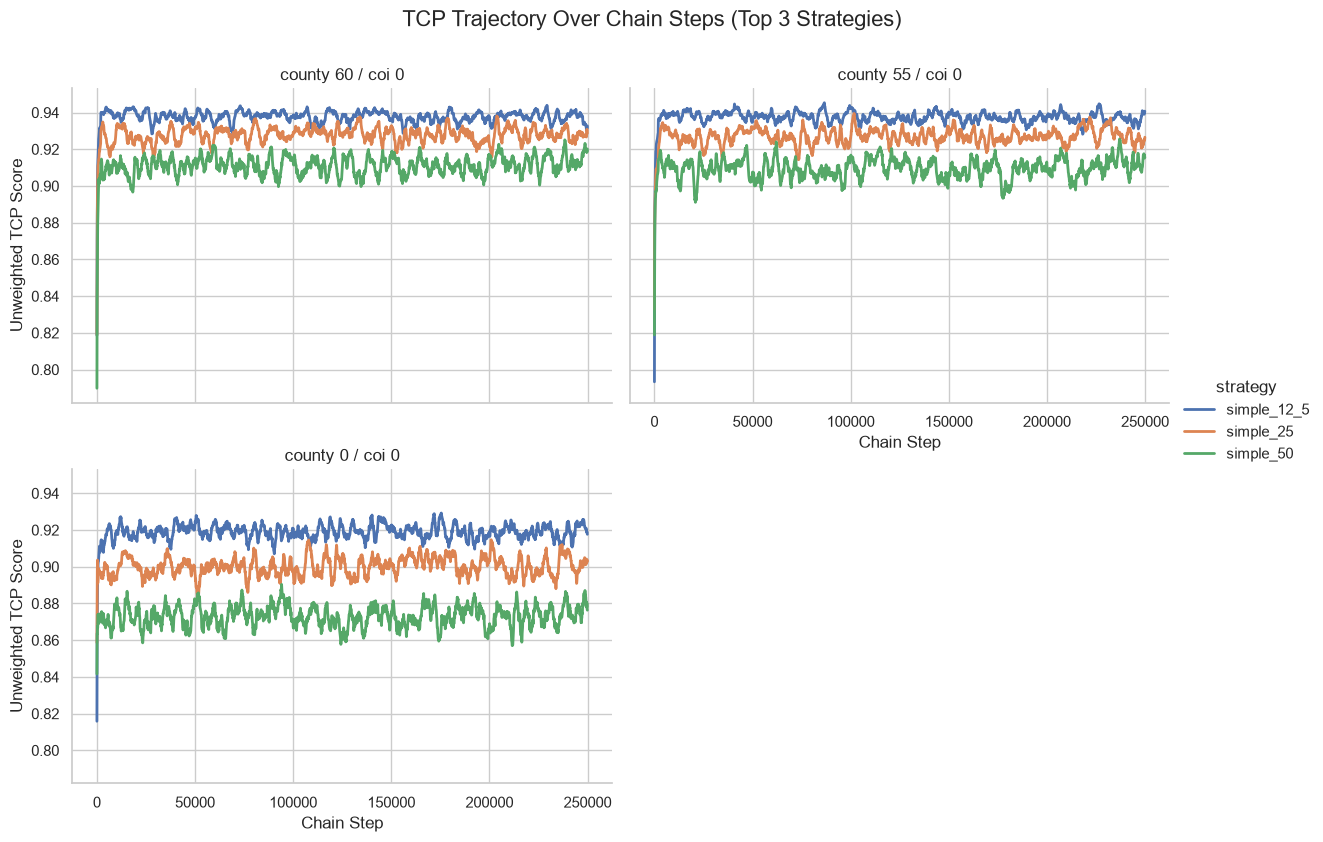

In [6]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    # filter based on the top 3 we think we like
    top_strategies = ['simple_12_5', 'simple_25', 'simple_50']
    filtered_obj_traces = obj_traces[obj_traces['strategy'].isin(top_strategies)].copy()
    grouped_obj_traces = filtered_obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())

    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2,
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (Top 3 Strategies)', y=1.05, fontsize=16)
    plt.show()
    


### Objective: CS

In [7]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    # filter based on the top 3 we think we like
    top_strategies = ['simple_12_5', 'simple_25', 'simple_50']
    filtered_obj_traces = obj_traces[obj_traces['strategy'].isin(top_strategies)].copy()
    grouped_obj_traces = filtered_obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
    grouped_obj_traces = grouped_obj_traces.sort_values(['surcharge_label', 'strategy', 'step'])
    grouped_obj_traces[TCP_COL] = grouped_obj_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
    
    g = sns.relplot(
        data=grouped_obj_traces,
        x='step',
        y=TCP_COL,
        hue='strategy',
        col='surcharge_label',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        linewidth=2,
    )
    g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('TCP Trajectory Over Chain Steps (Top 3 Strategies)', y=1.05, fontsize=16)
    plt.show()
    


## Rolling Acceptance Rate

the acceptance rate is the proportion of proposed maps that are accepted over a rolling window of 1,000 chain steps.


### Objective: TCP

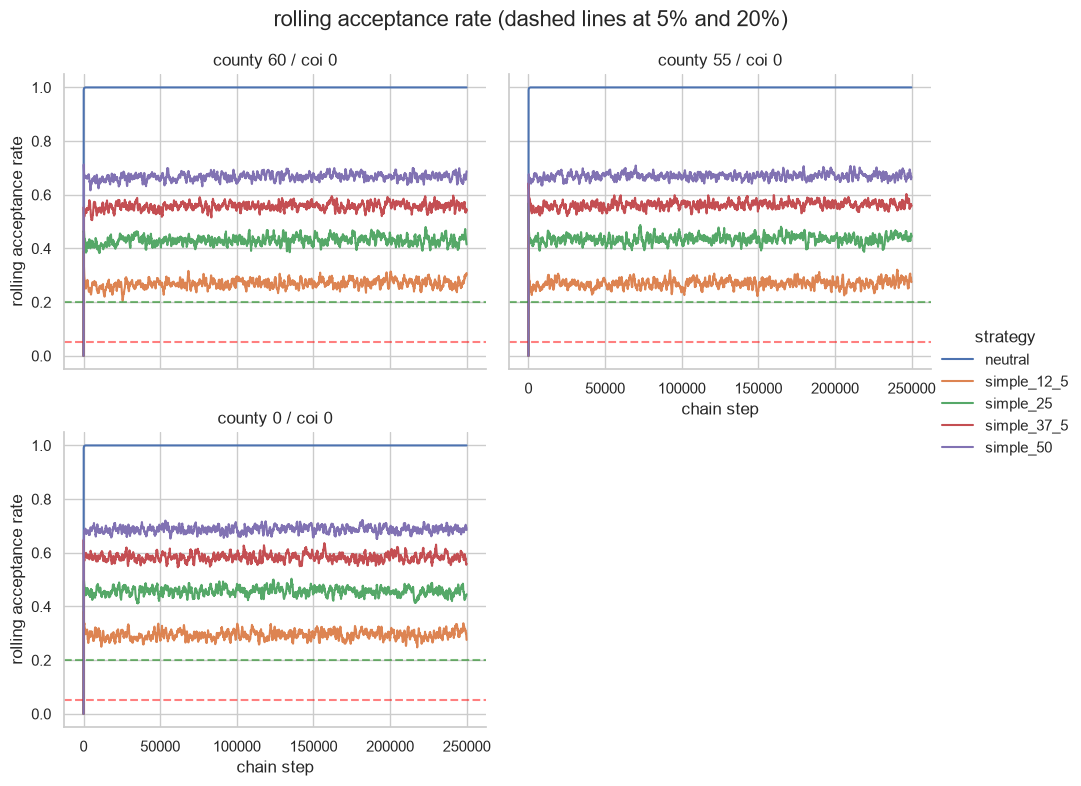

In [8]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### rolling acceptance rate by strategy, faceted by surcharge configuration
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    grouped_accept = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True)['rolling_accept_rate'].mean().reset_index()
    
    g = sns.relplot(
        data=grouped_accept,
        x="step",
        y="rolling_accept_rate",
        hue="strategy",
        col="surcharge_label",
        kind="line",
        height=4,
        aspect=1.2,
        col_wrap=2
    )
    
    for ax in g.axes.flat:
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
        ax.axhline(0.20, color='green', linestyle='--', alpha=0.5)
    
    g.set_axis_labels("chain step", "rolling acceptance rate")
    g.set_titles(col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("rolling acceptance rate (dashed lines at 5% and 20%)", fontsize=16)
    plt.show()
    
    

### Objective: CS

In [9]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### rolling acceptance rate by strategy, faceted by surcharge configuration
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    grouped_accept = obj_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True)['rolling_accept_rate'].mean().reset_index()
    
    g = sns.relplot(
        data=grouped_accept,
        x="step",
        y="rolling_accept_rate",
        hue="strategy",
        col="surcharge_label",
        kind="line",
        height=4,
        aspect=1.2,
        col_wrap=2
    )
    
    for ax in g.axes.flat:
        ax.axhline(0.05, color='red', linestyle='--', alpha=0.5)
        ax.axhline(0.20, color='green', linestyle='--', alpha=0.5)
    
    g.set_axis_labels("chain step", "rolling acceptance rate")
    g.set_titles(col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("rolling acceptance rate (dashed lines at 5% and 20%)", fontsize=16)
    plt.show()
    
    

## TCP Distributions By Strategy, Surcharge

we are looking for a strategy with a high median line and a fat upper body, indicating it consistently finds and preserves high-tcp maps.


### Objective: TCP

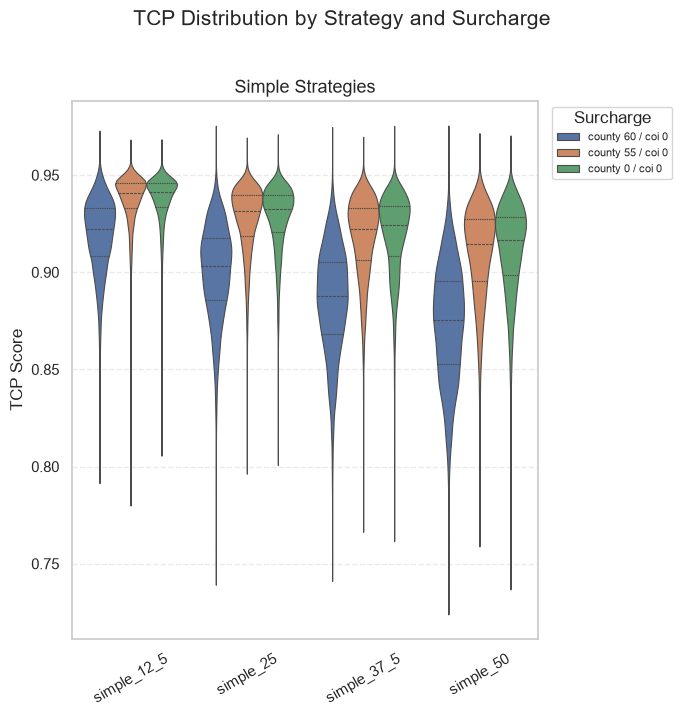

In [10]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    CLASS_ORDER = ['Proportional', 'Margin', 'Simple']
    valid_classes = [c for c in CLASS_ORDER if c in obj_traces['strategy_class'].unique()]
    
    fig, axes = plt.subplots(1, len(valid_classes), figsize=(7 * len(valid_classes), 7), sharey=True)
    if len(valid_classes) == 1:
        axes = [axes]
    
    for i, s_class in enumerate(valid_classes):
        subset = obj_traces[obj_traces['strategy_class'] == s_class].copy()
    
        ### get strategies in this class, sorted
        strats_in_class = sorted(subset['strategy'].unique())
        subset['strategy'] = pd.Categorical(subset['strategy'], categories=strats_in_class, ordered=True)
    
        sns.violinplot(
            data=subset,
            x='strategy',
            y=TCP_COL,
            hue='surcharge_label',
            ax=axes[i],
            cut=5,
            inner='quartile',
            linewidth=0.8,
            density_norm='width',
        )
    
        axes[i].set_title(f'{s_class} Strategies', fontsize=13)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)
    
        ### only show legend on last panel
        if i < len(valid_classes) - 1:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title='Surcharge', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    
    axes[0].set_ylabel('TCP Score')
    fig.suptitle('TCP Distribution by Strategy and Surcharge', fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
    
    

### Objective: CS

In [11]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    CLASS_ORDER = ['Proportional', 'Margin', 'Simple']
    valid_classes = [c for c in CLASS_ORDER if c in obj_traces['strategy_class'].unique()]
    
    fig, axes = plt.subplots(1, len(valid_classes), figsize=(7 * len(valid_classes), 7), sharey=True)
    if len(valid_classes) == 1:
        axes = [axes]
    
    for i, s_class in enumerate(valid_classes):
        subset = obj_traces[obj_traces['strategy_class'] == s_class].copy()
    
        ### get strategies in this class, sorted
        strats_in_class = sorted(subset['strategy'].unique())
        subset['strategy'] = pd.Categorical(subset['strategy'], categories=strats_in_class, ordered=True)
    
        sns.violinplot(
            data=subset,
            x='strategy',
            y=TCP_COL,
            hue='surcharge_label',
            ax=axes[i],
            cut=5,
            inner='quartile',
            linewidth=0.8,
            density_norm='width',
        )
    
        axes[i].set_title(f'{s_class} Strategies', fontsize=13)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)
    
        ### only show legend on last panel
        if i < len(valid_classes) - 1:
            axes[i].get_legend().remove()
        else:
            axes[i].legend(title='Surcharge', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    
    axes[0].set_ylabel('TCP Score')
    fig.suptitle('TCP Distribution by Strategy and Surcharge', fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
    
    

## Summary Table
aggregated stats per strategy x surcharge combination.


In [12]:
if len(master_df) > 0:
    ### mean tcp by strategy x surcharge
    pivot = master_df.pivot_table(
        index=['objective', 'strategy'],
        columns='surcharge_label',
        values='mean_tcp',
        aggfunc='mean'
    ).round(4)
    
    print('mean tcp by strategy x surcharge:')
    display(pivot)
    
    ### same for county splits
    pivot_splits = master_df.pivot_table(
        index=['objective', 'strategy'],
        columns='surcharge_label',
        values='mean_county_splits',
        aggfunc='mean'
    ).round(2)
    
    print('\nmean county splits by strategy x surcharge:')
    display(pivot_splits)
    


mean tcp by strategy x surcharge:


surcharge_label        county 0 / coi 0  county 55 / coi 0  county 60 / coi 0
objective strategy                                                           
tcp       neutral                0.8400             0.8847             0.8871
          simple_12_5            0.9186             0.9374             0.9377
          simple_25              0.9000             0.9271             0.9278
          simple_37_5            0.8853             0.9177             0.9190
          simple_50              0.8730             0.9096             0.9116


mean county splits by strategy x surcharge:


surcharge_label        county 0 / coi 0  county 55 / coi 0  county 60 / coi 0
objective strategy                                                           
tcp       neutral                 21.36               9.96               8.85
          simple_12_5             21.08               9.52               8.63
          simple_25               21.15               9.62               8.67
          simple_37_5             21.26               9.66               8.66
          simple_50               21.31               9.72               8.72

## Check Mix

### Objective: TCP

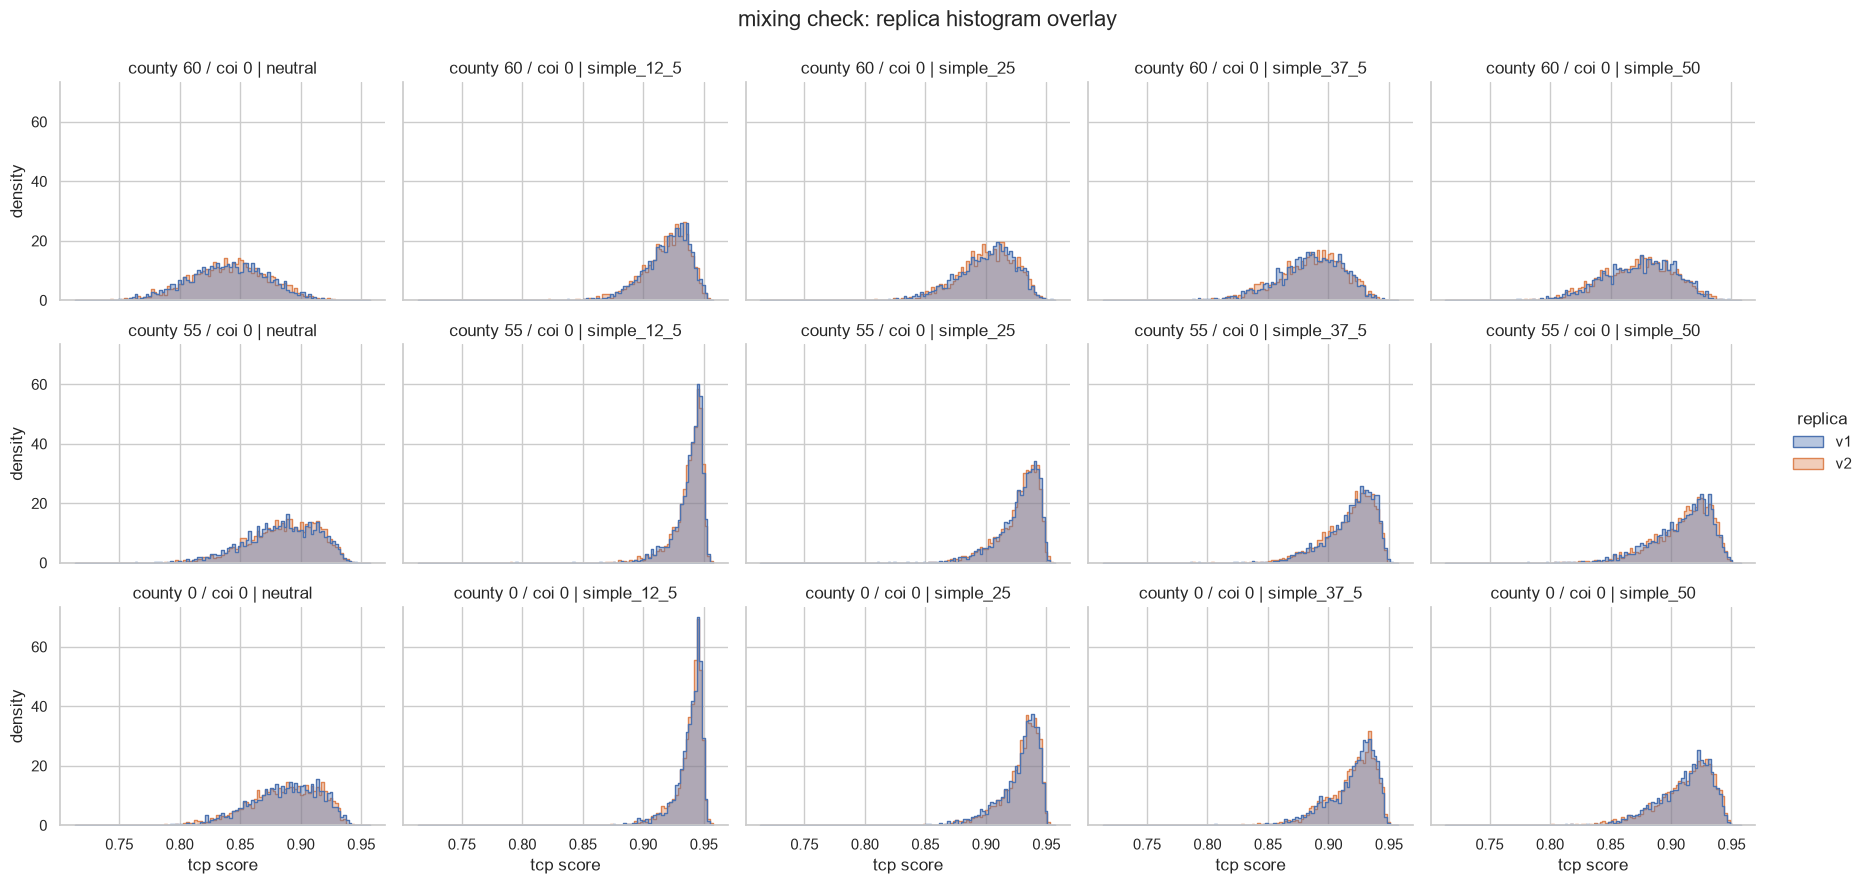

In [13]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### overlay tcp histograms for v1 and v2
    g = sns.displot(
        data=obj_traces,
        x=TCP_COL,
        hue='replica',
        row='surcharge_label',
        col='strategy',
        kind='hist',
        element='step',
        stat='density',
        common_norm=False,
        height=3,
        aspect=1.2,
        alpha=0.4
    )
    
    g.set_axis_labels("tcp score", "density")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("mixing check: replica histogram overlay", fontsize=16)
    plt.show()
    
    

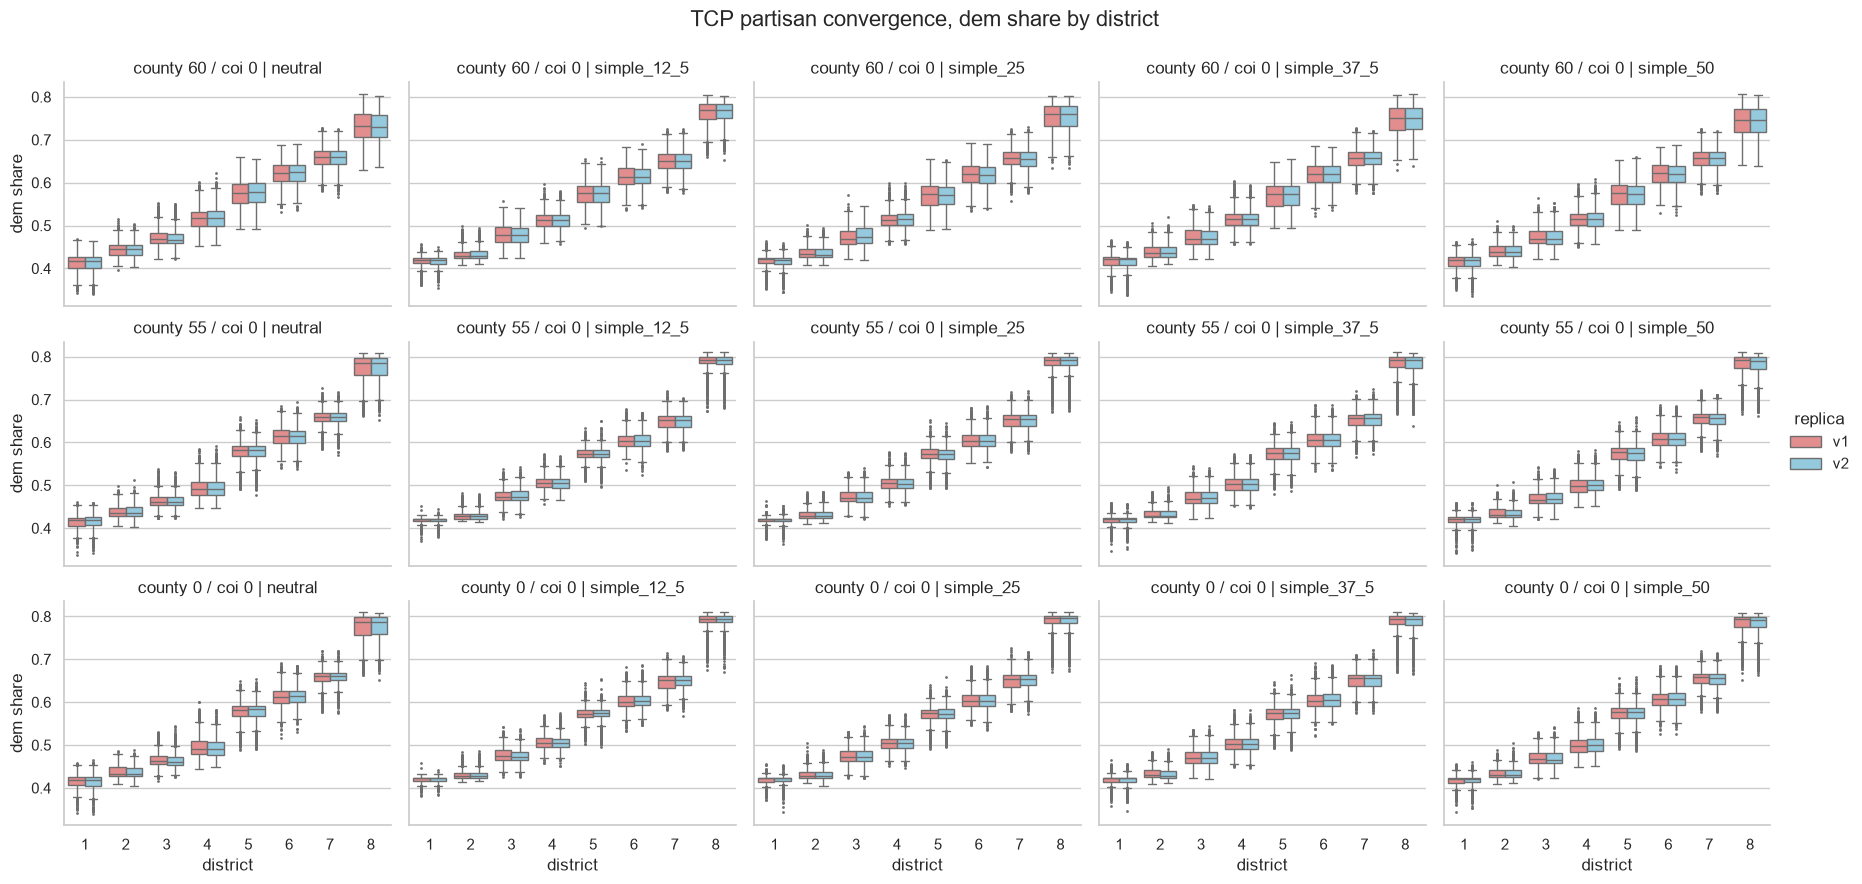

In [14]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    n_districts = obj_traces.filter(like='dist_').shape[1]
    if n_districts > 0:
        share_cols = [f'dist_{i}_dem_share' for i in range(1, n_districts + 1)]
        
        # melt the dataframe to facet by district
        melted = pd.melt(
            obj_traces, 
            id_vars=['replica', 'strategy', 'surcharge_label'], 
            value_vars=share_cols, 
            var_name='district', 
            value_name='dem_share'
        )
        
        # simplify the x labels from 'dist_1_dem_share' to '1'
        melted['district'] = melted['district'].str.extract(r'dist_(\d+)_').astype(int)
        
        # faceted boxplots
        g = sns.catplot(
            data=melted,
            x='district',
            y='dem_share',
            hue='replica',
            row='surcharge_label',
            col='strategy',
            kind='box',
            height=3,
            aspect=1.2,
            fliersize=1,
            linewidth=1,
            palette={'v1': 'lightcoral', 'v2': 'skyblue'}
        )
        
        g.set_axis_labels('district', 'dem share')
        g.set_titles(row_template='{row_name}', col_template='{col_name}')
        
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle(f'{objective.upper()} partisan convergence, dem share by district', fontsize=16)
        plt.show()


### Objective: CS

In [15]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### overlay tcp histograms for v1 and v2
    g = sns.displot(
        data=obj_traces,
        x=TCP_COL,
        hue='replica',
        row='surcharge_label',
        col='strategy',
        kind='hist',
        element='step',
        stat='density',
        common_norm=False,
        height=3,
        aspect=1.2,
        alpha=0.4
    )
    
    g.set_axis_labels("tcp score", "density")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("mixing check: replica histogram overlay", fontsize=16)
    plt.show()
    
    

In [16]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    n_districts = obj_traces.filter(like='dist_').shape[1]
    if n_districts > 0:
        share_cols = [f'dist_{i}_dem_share' for i in range(1, n_districts + 1)]
        
        # melt the dataframe to facet by district
        melted = pd.melt(
            obj_traces, 
            id_vars=['replica', 'strategy', 'surcharge_label'], 
            value_vars=share_cols, 
            var_name='district', 
            value_name='dem_share'
        )
        
        # simplify the x labels from 'dist_1_dem_share' to '1'
        melted['district'] = melted['district'].str.extract(r'dist_(\d+)_').astype(int)
        
        # faceted boxplots
        g = sns.catplot(
            data=melted,
            x='district',
            y='dem_share',
            hue='replica',
            row='surcharge_label',
            col='strategy',
            kind='box',
            height=3,
            aspect=1.2,
            fliersize=1,
            linewidth=1,
            palette={'v1': 'lightcoral', 'v2': 'skyblue'}
        )
        
        g.set_axis_labels('district', 'dem share')
        g.set_titles(row_template='{row_name}', col_template='{col_name}')
        
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle(f'{objective.upper()} partisan convergence, dem share by district', fontsize=16)
        plt.show()


# Matrix Density Plots

## Pareto Frontier: TCP vs County Splits

tradeoff: we want to maximize coi preservation (tcp) while minimizing county splits. so, the ideal maps are sit in the **top-left corner of the plots.**


### Objective: TCP

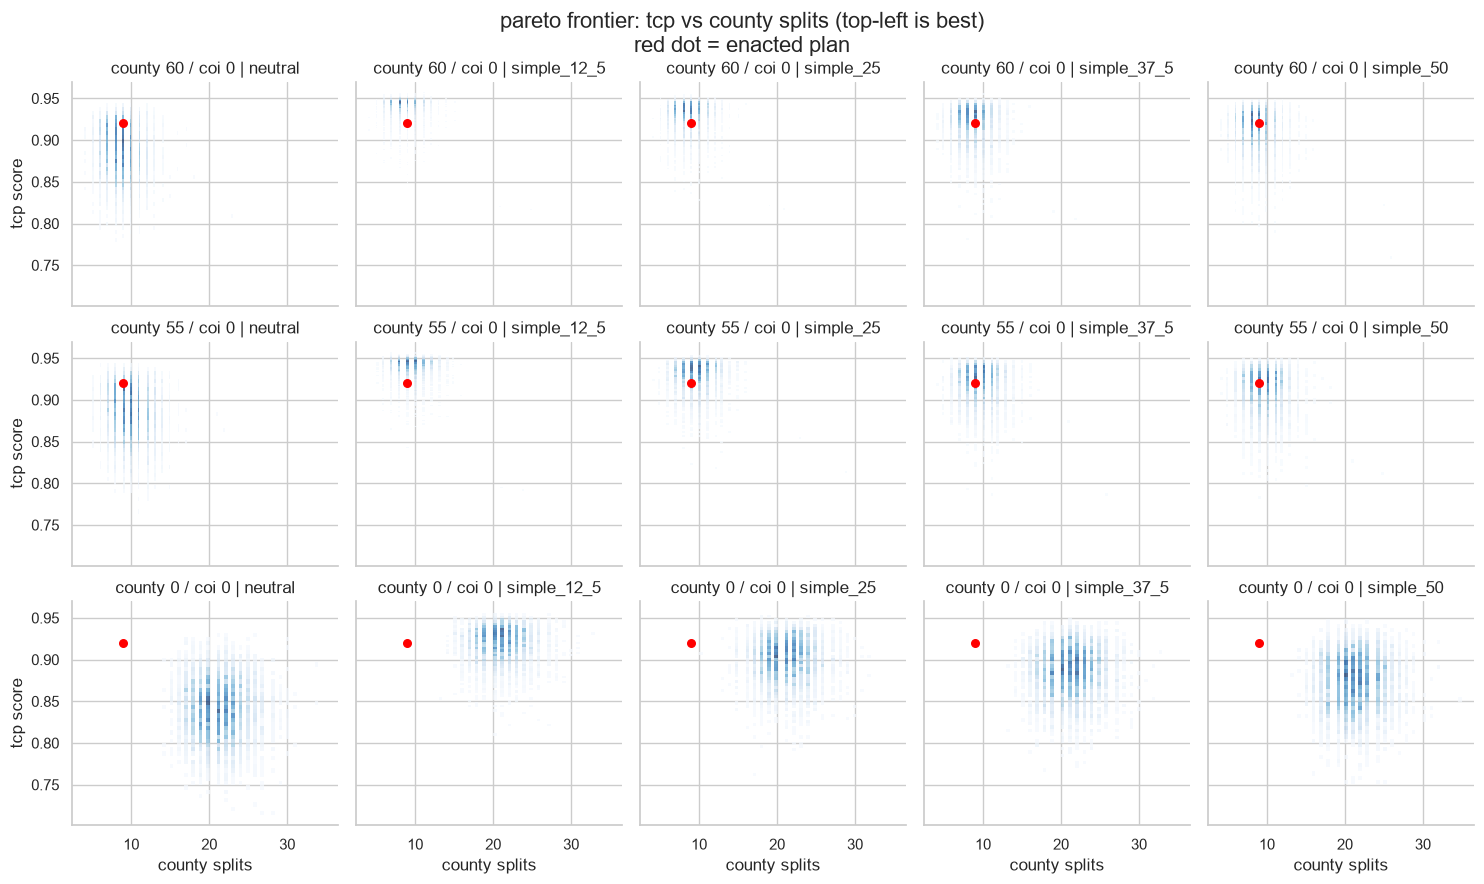

In [41]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs county splits
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
    )
    g.map_dataframe(sns.histplot, x="county_split_count", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    g.map(plt.scatter, x=[9], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    g.set_axis_labels("county splits", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("pareto frontier: tcp vs county splits (top-left is best)\nred dot = enacted plan", fontsize=16)
    plt.show()
    
    

### Objective: CS

In [18]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs county splits
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
    )
    g.map_dataframe(sns.histplot, x="county_split_count", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    g.map(plt.scatter, x=[9], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    g.set_axis_labels("county splits", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("pareto frontier: tcp vs county splits (top-left is best)\nred dot = enacted plan", fontsize=16)
    plt.show()
    
    

## Dem Wins vs TCP

evaluating how the acceptance functions and surcharge constraints affect the partisan performance of the map. here we plot total tcp score against the number of democratic wins. this gives us insight into the distribution of partisan outcomes in the generated ensemble, and how preservation goals shape those outcomes.

### Objective: TCP

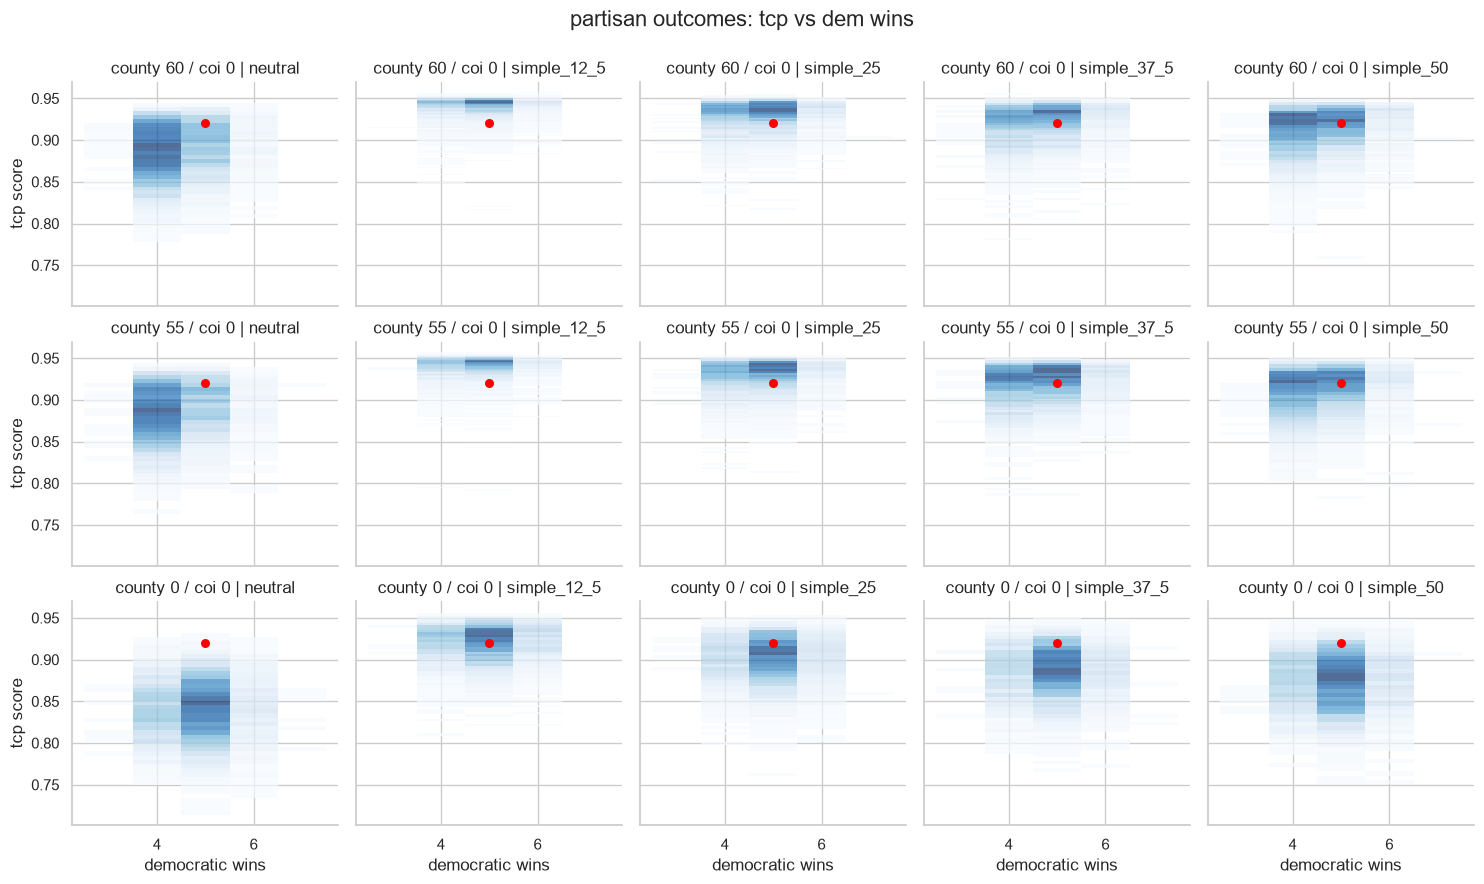

In [19]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs dem wins
    if 'dem_wins' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.histplot, x="dem_wins", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0, discrete=(True, False))
        g.map(plt.scatter, x=[5], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("democratic wins", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs dem wins", fontsize=16)
        plt.show()
    else:
        print('dem_wins not found in data')
    
    

### Objective: CS

In [20]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### pareto frontier: tcp vs dem wins
    if 'dem_wins' in obj_traces.columns:
        g = sns.FacetGrid(
            obj_traces,
            row="surcharge_label",
            col="strategy",
        )
        g.map_dataframe(sns.histplot, x="dem_wins", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0, discrete=(True, False))
        g.map(plt.scatter, x=[5], y=[0.92], color="red", s=30, zorder=10, label="Enacted Plan")
        g.set_axis_labels("democratic wins", "tcp score")
        g.set_titles(row_template="{row_name}", col_template="{col_name}")
        plt.subplots_adjust(top=0.9)
        g.fig.suptitle("partisan outcomes: tcp vs dem wins", fontsize=16)
        plt.show()
    else:
        print('dem_wins not found in data')
    
    

### Joint Plots

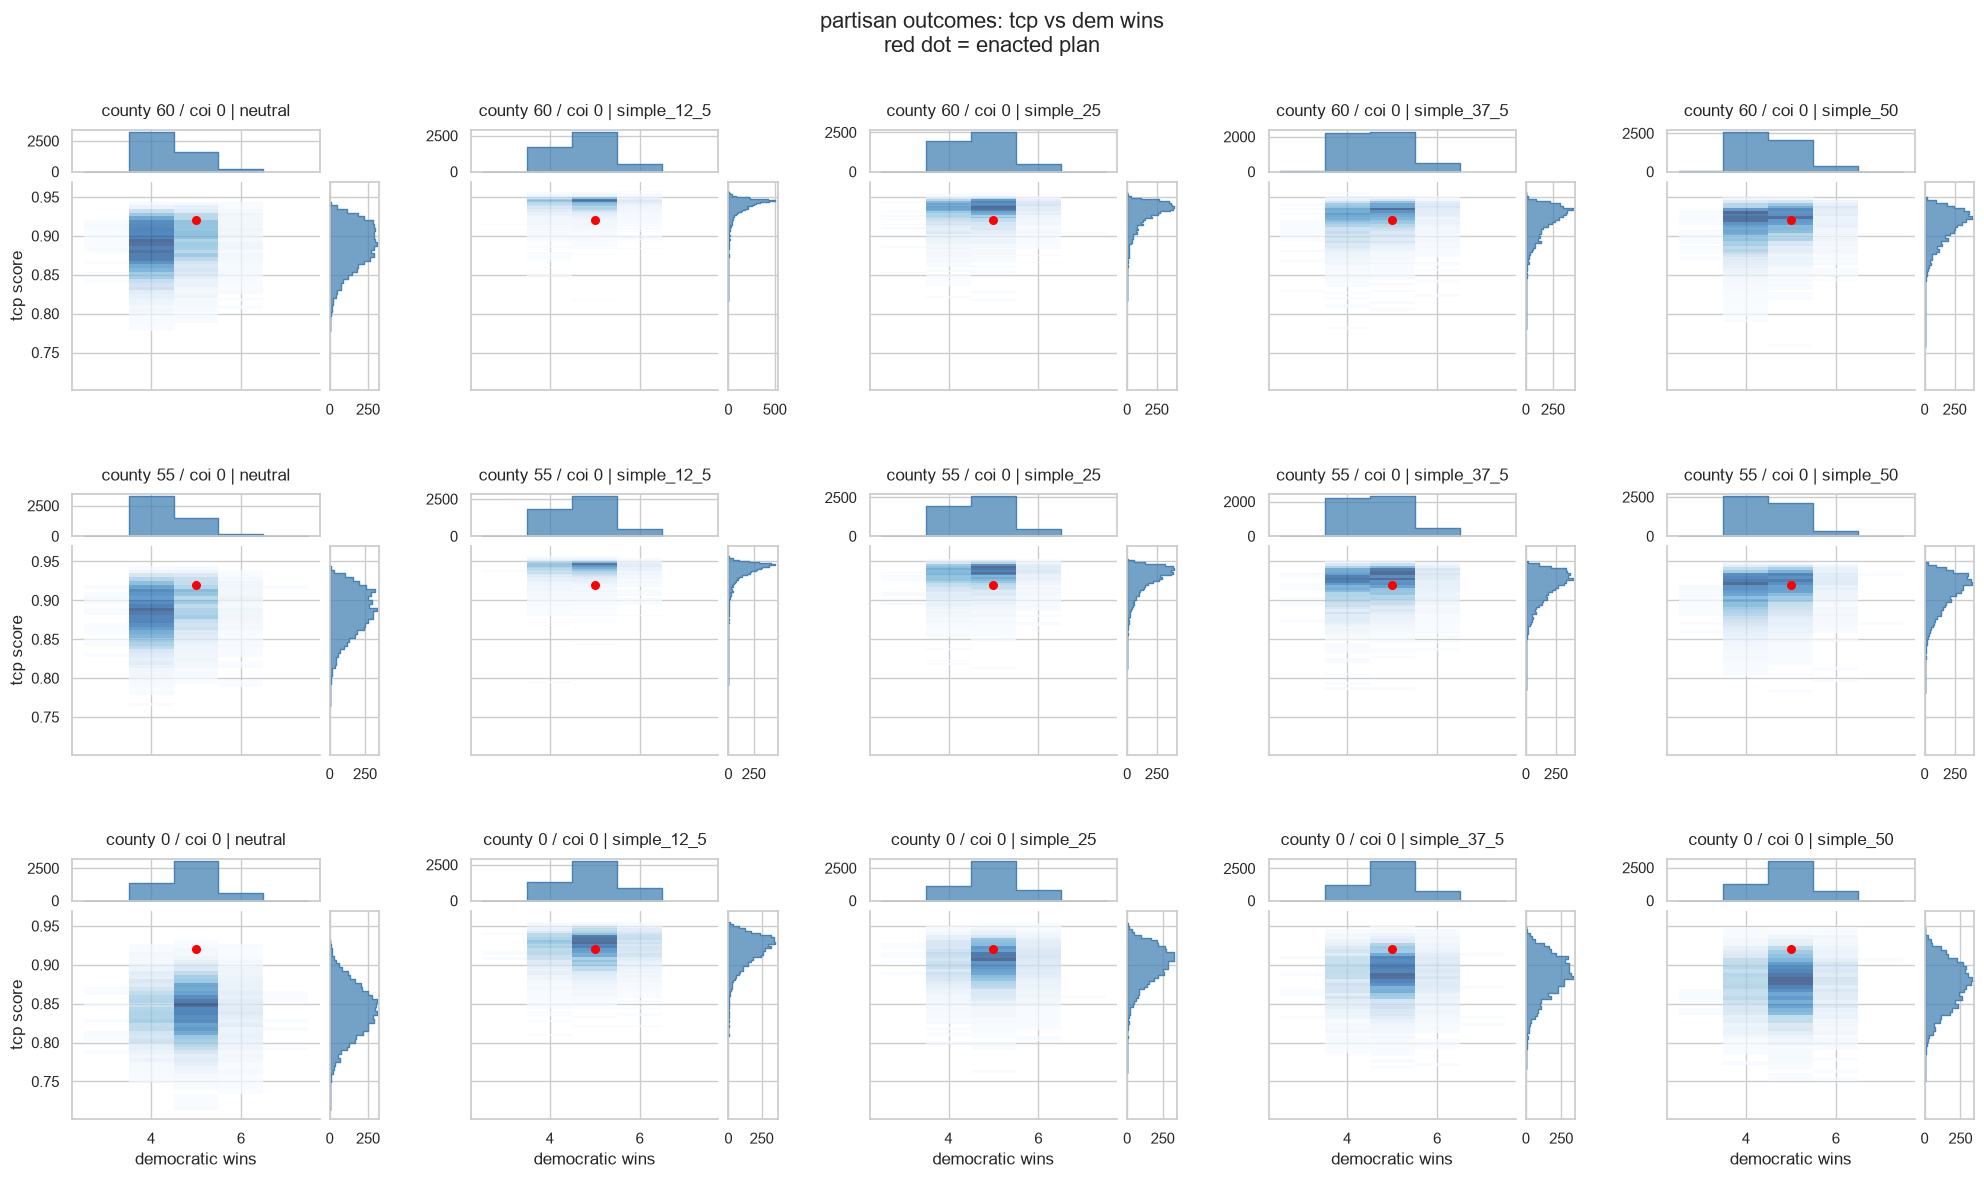

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Update the custom function for the Dem Wins layout
def facet_jointplot_dem(data, x, y, **kwargs):
    ax = plt.gca()
    
    # Plot the main 2D histogram (notice the discrete parameter for the x-axis)
    sns.histplot(
        data=data, x=x, y=y, 
        fill=True, alpha=0.7, cmap="Blues", linewidths=0, 
        discrete=(True, False), ax=ax
    )
    
    # Plot the Enacted Plan dot (Moved to 5 dem wins)
    ax.scatter([5], [0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    # Create marginal axes attached to the current facet
    divider = make_axes_locatable(ax)
    ax_histx = divider.append_axes("top", size="20%", pad=0.1, sharex=ax)
    ax_histy = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)
    
    # Plot the 1D marginal histograms on the new axes (x is discrete)
    sns.histplot(data=data, x=x, ax=ax_histx, color="steelblue", element="step", discrete=True)
    sns.histplot(data=data, y=y, ax=ax_histy, color="steelblue", element="step")
    
    # Hide the ticks and labels on the marginal axes to keep the grid clean
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histx.set_xlabel('')
    ax_histx.set_ylabel('')
    ax_histy.set_xlabel('')
    ax_histy.set_ylabel('')

    # Extract the facet parameters and set the title on the top marginal
    if not data.empty:
        row_val = data['surcharge_label'].iloc[0]
        col_val = data['strategy'].iloc[0]
        title_str = f"{row_val} | {col_val}"
        ax_histx.set_title(title_str, fontsize=12, pad=10)

# 2. Filter data
obj_traces = traces[traces['objective'] == 'tcp']

if len(obj_traces) > 0 and 'dem_wins' in obj_traces.columns:
    # 3. Create the FacetGrid
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=4
    )
    
    # 4. Map the custom Dem Wins function
    g.map_dataframe(facet_jointplot_dem, x="dem_wins", y=TCP_COL)
    
    # 5. Format labels and titles
    g.set_axis_labels("democratic wins", "tcp score")
    
    # Remove Seaborn's default title generation completely
    g.set_titles("") 
    
    # Adjust spacing so the marginals don't overlap the titles
    plt.subplots_adjust(top=0.88, wspace=0.3, hspace=0.4)
    g.fig.suptitle("partisan outcomes: tcp vs dem wins\nred dot = enacted plan", fontsize=16)
    
    plt.show()
elif len(obj_traces) > 0:
    print('dem_wins not found in data')

## TCP vs Community Splits

this plot explores where the tcp metric diverges from the traditional "binary community splits" metric, answering two key questions:

**1. how can a map have high tcp but *terrible* (high) community splits? (bottom-right)**
- **the"nibble:** if a mapmaker splits 20 communities, but splits them 95%-5% to balance population, the binary metric penalizes them 20 times. however, the tcp math ($0.95^2 + 0.05^2 = 0.905$) remains high. tcp gracefully forgives minor population balancing nibbles as aligned with the state legislation to keep coi's as whole as possible.

**2. how can a map have low tcp but *good* (low) community splits? (top-left)**
- **the perfect crack:** if a mapmaker only splits 5 communities, the binary metric looks great. but if those 5 communities are split exactly 50%-50%, the tcp math plummets ($0.5^2 + 0.5^2 = 0.5$).


### Objective: TCP

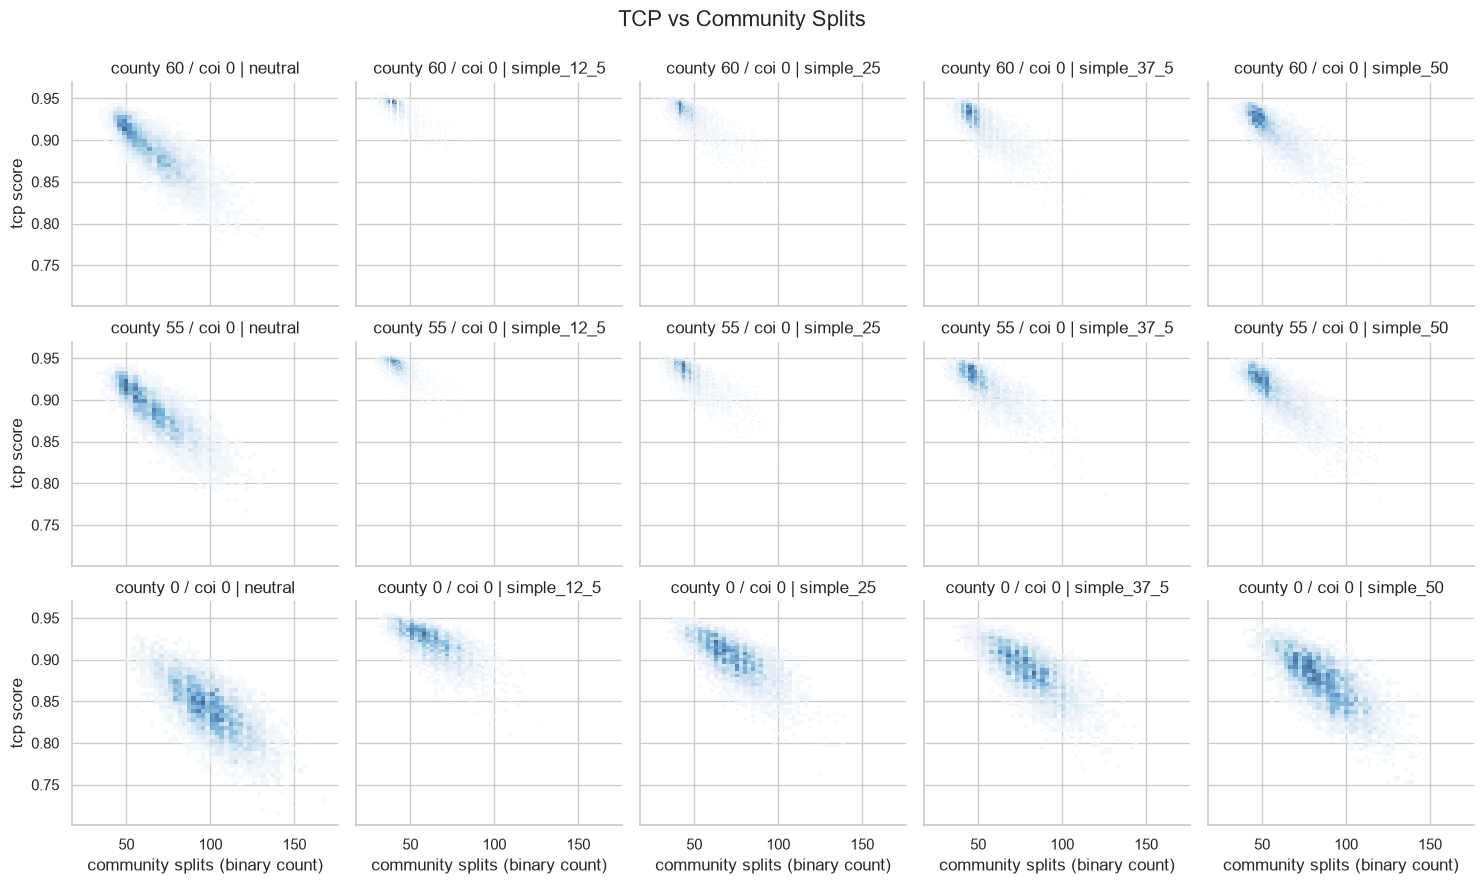

In [42]:
obj_traces = traces[traces['objective'] == 'tcp']
if len(obj_traces) > 0:
    ### tcp vs community splits to identify gaming regions
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=3,
        aspect=1
    )
    g.map_dataframe(sns.histplot, x="communities_split", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    
    g.set_axis_labels("community splits (binary count)", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("TCP vs Community Splits", fontsize=16)
    plt.show()
    
    

### Objective: CS

In [43]:
obj_traces = traces[traces['objective'] == 'cs']
if len(obj_traces) > 0:
    ### tcp vs community splits to identify gaming regions
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=3,
        aspect=1
    )
    g.map_dataframe(sns.histplot, x="communities_split", y=TCP_COL, fill=True, alpha=0.7, cmap="Blues", linewidths=0)
    
    g.set_axis_labels("community splits (binary count)", "tcp score")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle("TCP vs Community Splits", fontsize=16)
    plt.show()
    
    

### Joint Plots

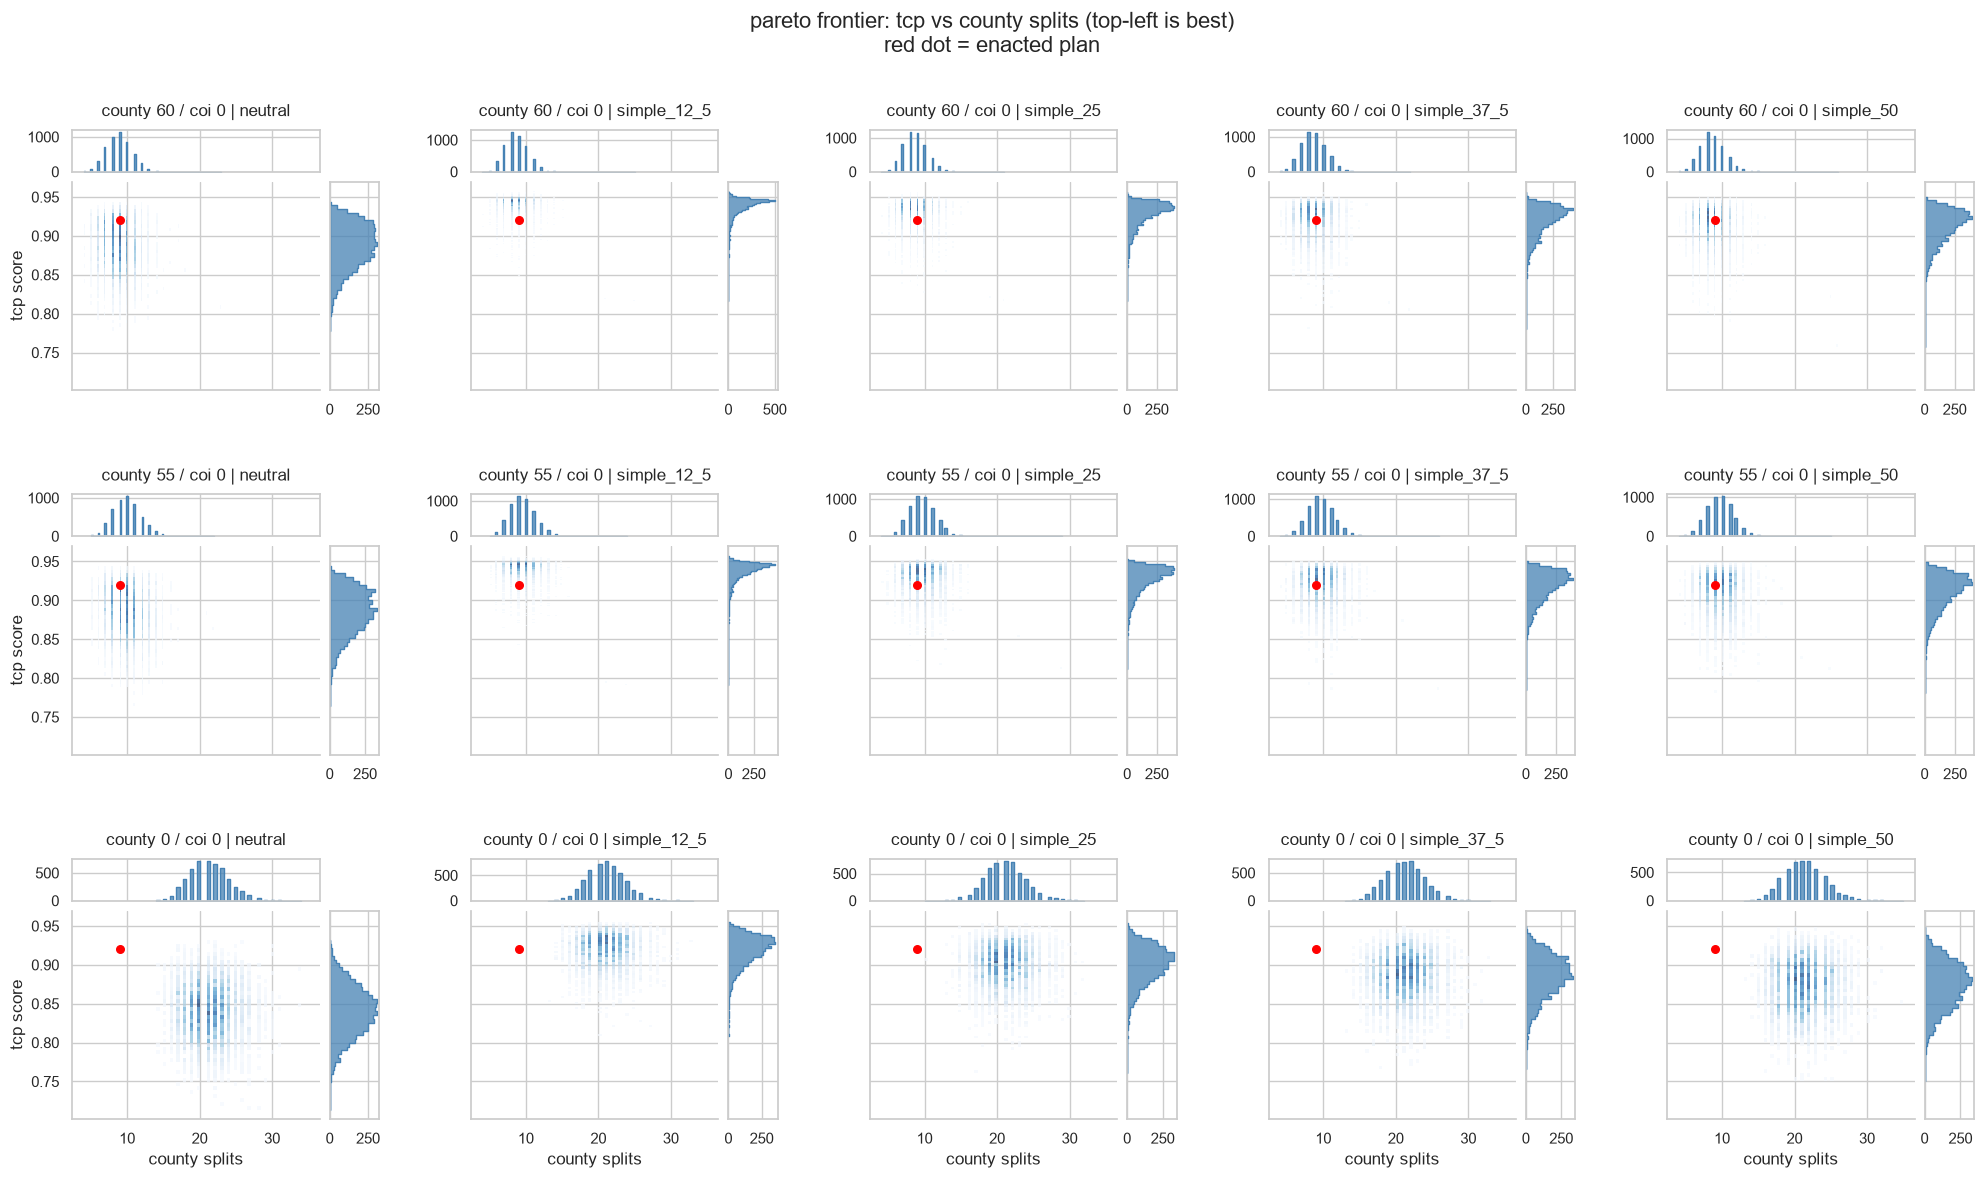

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Update the custom function to extract labels and place them on the top axis
def facet_jointplot(data, x, y, **kwargs):
    ax = plt.gca()
    
    # Plot the main 2D histogram
    sns.histplot(
        data=data, x=x, y=y, 
        fill=True, alpha=0.7, cmap="Blues", linewidths=0, ax=ax
    )
    
    # Plot the Enacted Plan dot
    ax.scatter([9], [0.92], color="red", s=30, zorder=10, label="Enacted Plan")
    
    # Create marginal axes attached to the current facet
    divider = make_axes_locatable(ax)
    ax_histx = divider.append_axes("top", size="20%", pad=0.1, sharex=ax)
    ax_histy = divider.append_axes("right", size="20%", pad=0.1, sharey=ax)
    
    # Plot the 1D marginal histograms on the new axes
    sns.histplot(data=data, x=x, ax=ax_histx, color="steelblue", element="step")
    sns.histplot(data=data, y=y, ax=ax_histy, color="steelblue", element="step")
    
    # Hide the ticks and labels on the marginal axes to keep the grid clean
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histx.set_xlabel('')
    ax_histx.set_ylabel('')
    ax_histy.set_xlabel('')
    ax_histy.set_ylabel('')

    # --- NEW: Extract the facet parameters and set the title on the top marginal ---
    if not data.empty:
        row_val = data['surcharge_label'].iloc[0]
        col_val = data['strategy'].iloc[0]
        # Format the title exactly like your scatterplot example
        title_str = f"{row_val} | {col_val}"
        ax_histx.set_title(title_str, fontsize=12, pad=10)

# 2. Filter data
obj_traces = traces[traces['objective'] == 'tcp']

if len(obj_traces) > 0:
    # 3. Create the FacetGrid
    # Removed margin_titles=True so Seaborn doesn't fight our custom titles
    g = sns.FacetGrid(
        obj_traces,
        row="surcharge_label",
        col="strategy",
        height=4
    )
    
    # 4. Map the custom function
    g.map_dataframe(facet_jointplot, x="county_split_count", y=TCP_COL)
    
    # 5. Format labels and titles
    g.set_axis_labels("county splits", "tcp score")
    
    # Remove Seaborn's default title generation completely, since our function handles it
    g.set_titles("") 
    
    # Adjust spacing so the marginals don't overlap the titles
    plt.subplots_adjust(top=0.88, wspace=0.3, hspace=0.4)
    g.fig.suptitle("pareto frontier: tcp vs county splits (top-left is best)\nred dot = enacted plan", fontsize=16)
    
    plt.show()

## Calculate 'Best' 

In [45]:
## enacted map
TARGET_SPLITS = 9
TARGET_TCP = 0.92

### Best County Splits

In [46]:
def calculate_kde_density(df, x_col, y_col, target_x, target_y):
    pts = df[[x_col, y_col]].dropna().values.T
    
    try:
        kde = gaussian_kde(pts)
        density = kde.evaluate([target_x, target_y])[0]
        return density
    except np.linalg.LinAlgError:
        return np.nan


results = []
for name, group in obj_traces.groupby(['surcharge_label', 'strategy']):
    density = calculate_kde_density(group, "county_split_count", TCP_COL, TARGET_SPLITS, TARGET_TCP)
    results.append({
        'surcharge_label': name[0],
        'strategy': name[1],
        'kde_density': density
    })

# convert to df and sort by highest density to lowest density (closest to the mode)
ranking_df = pd.DataFrame(results).sort_values('kde_density', ascending=False).reset_index(drop=True)

print("Ranking of plots (highest density = closest to the mode):")
display(ranking_df.style.background_gradient(subset=['kde_density'], cmap='Blues'))

Ranking of plots (highest density = closest to the mode):


,surcharge_label,strategy,kde_density
0,county 60 / coi 0,simple_37_5,4.293385
1,county 55 / coi 0,simple_37_5,4.226242
2,county 60 / coi 0,simple_50,3.943402
3,county 55 / coi 0,simple_50,3.910711
4,county 60 / coi 0,simple_25,3.400890
5,county 55 / coi 0,simple_25,3.329798
6,county 60 / coi 0,neutral,2.286591
7,county 55 / coi 0,neutral,1.940431
8,county 60 / coi 0,simple_12_5,1.604235
9,county 55 / coi 0,simple_12_5,1.485036


### Best Dem Wins

In [50]:
TARGET_DEM_WINS = 5
TARGET_TCP = 0.92

if 'dem_wins' in obj_traces.columns:
    results_dem_kde = []
    for name, group in obj_traces.groupby(['surcharge_label', 'strategy']):
        density = calculate_kde_density(group, "dem_wins", TCP_COL, TARGET_DEM_WINS, TARGET_TCP)
        results_dem_kde.append({
            'surcharge_label': name[0],
            'strategy': name[1],
            'kde_density': density
        })
    
    ranking_df_dem_kde = pd.DataFrame(results_dem_kde).sort_values('kde_density', ascending=False).reset_index(drop=True)
    
    print("\nRanking of plots (highest density = closest to the mode for Dem Wins):")
    display(ranking_df_dem_kde.style.background_gradient(subset=['kde_density'], cmap='Blues'))

else:
    print("'dem_wins' not found in data.")


Ranking of plots (highest density = closest to the mode for Dem Wins):


,surcharge_label,strategy,kde_density
0,county 0 / coi 0,simple_12_5,27.145389
1,county 0 / coi 0,simple_25,23.694017
2,county 55 / coi 0,simple_37_5,22.167086
3,county 60 / coi 0,simple_50,22.020582
4,county 55 / coi 0,simple_50,21.185485
5,county 60 / coi 0,simple_37_5,21.165896
6,county 55 / coi 0,simple_25,18.884700
7,county 60 / coi 0,simple_25,17.322972
8,county 0 / coi 0,simple_37_5,13.118616
9,county 60 / coi 0,neutral,10.980138
